# Лабораторная работа №1 
### (Ковалев А.В. ИУ5-63Б)
## Текстовое описание выбранного набора данных
Для произведения первой лабораторной работы был выбран датасет "Hotel booking" (https://www.kaggle.com/datasets/mojtaba142/hotel-booking), содержащий информацию о бронях двух отелей (Resort Hotel и City Hotel) в период с 1-ого июля 2015-ого года по 31-ое августа 2017-ого года.

## Основные характеристики датасета
Данный дадасет содержит 36 признаков (без пропусков), 119390 записей и весит 24,5 Кб.
Загрузка данных датасета в датафрейм и их более подробное описание представлены ниже.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 

filename = 'hotel_booking.csv'
df = pd.read_csv(filename)

info = df.info()
df.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.00,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,Transient,96.14,0,0,Check-Out,2017-09-06,Claudia Johnson,Claudia.J@yahoo.com,403-092-5582,************8647
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,Transient,225.43,0,2,Check-Out,2017-09-07,Wesley Aguilar,WAguilar@xfinity.com,238-763-0612,************4333
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,Transient,157.71,0,4,Check-Out,2017-09-07,Mary Morales,Mary_Morales@hotmail.com,395-518-4100,************1821
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,Transient,104.40,0,0,Check-Out,2017-09-07,Caroline Conley MD,MD_Caroline@comcast.net,531-528-1017,************7860


## Визуальное исследование датасета.
### 1. Поиск наиболее загруженного бронями месяца для берегового и городского отелей. 

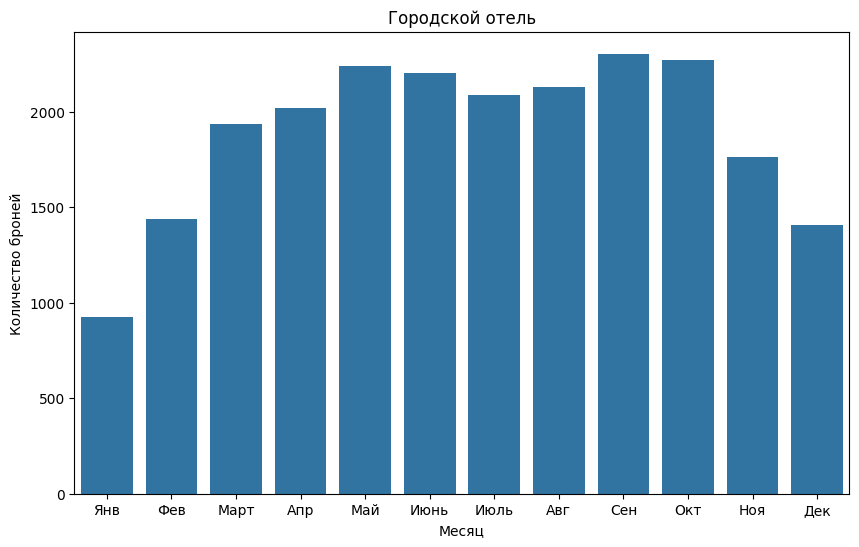

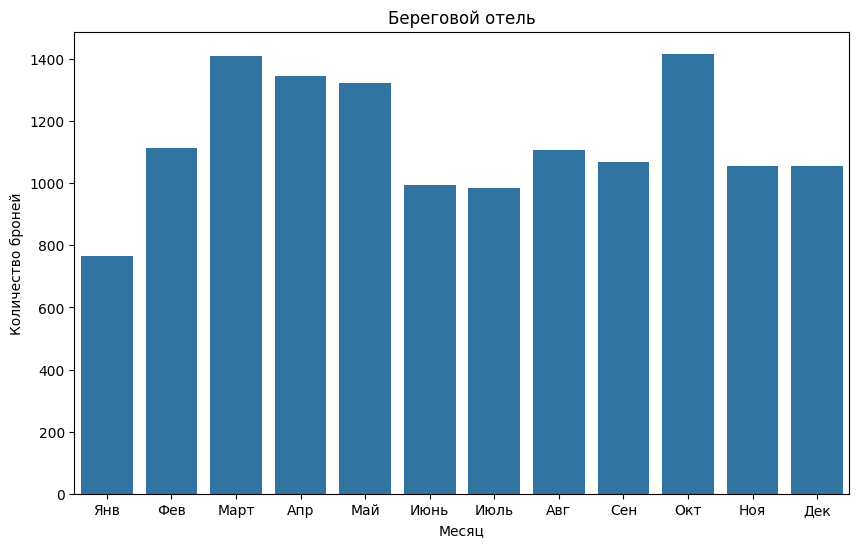

In [2]:
temp_df = df[df['is_canceled']==0]

plt.figure(figsize=(10, 6))
sns.countplot(x='arrival_date_month', data = temp_df[(temp_df['arrival_date_year']==2016) & (temp_df['hotel']=='City Hotel')])
plt.title('Городской отель')
plt.xlabel('Месяц')
plt.ylabel('Количество броней')
plt.xticks(ticks=[0,1,2,3,4,5,6,7,8,9,10,11], labels=['Янв','Фев','Март','Апр','Май','Июнь','Июль','Авг','Сен','Окт','Ноя','Дек'])

plt.figure(figsize=(10, 6))
sns.countplot(x='arrival_date_month', data = temp_df[(temp_df['arrival_date_year']==2016) & (temp_df['hotel']=='Resort Hotel')])
plt.title('Береговой отель')
plt.xlabel('Месяц')
plt.ylabel('Количество броней')
plt.xticks(ticks=[0,1,2,3,4,5,6,7,8,9,10,11], labels=['Янв','Фев','Март','Апр','Май','Июнь','Июль','Авг','Сен','Окт','Ноя','Дек'])
plt.show()

#### Результаты данного пункта анализа
- Наиболее загруженным месяцем для берегового отеля является октябрь.
- Наиболее загруженным месяцем для городского отеля вяляется сентябрь.
### 2. Установеление наличия зависимости процента отклонения от типа покупателя.

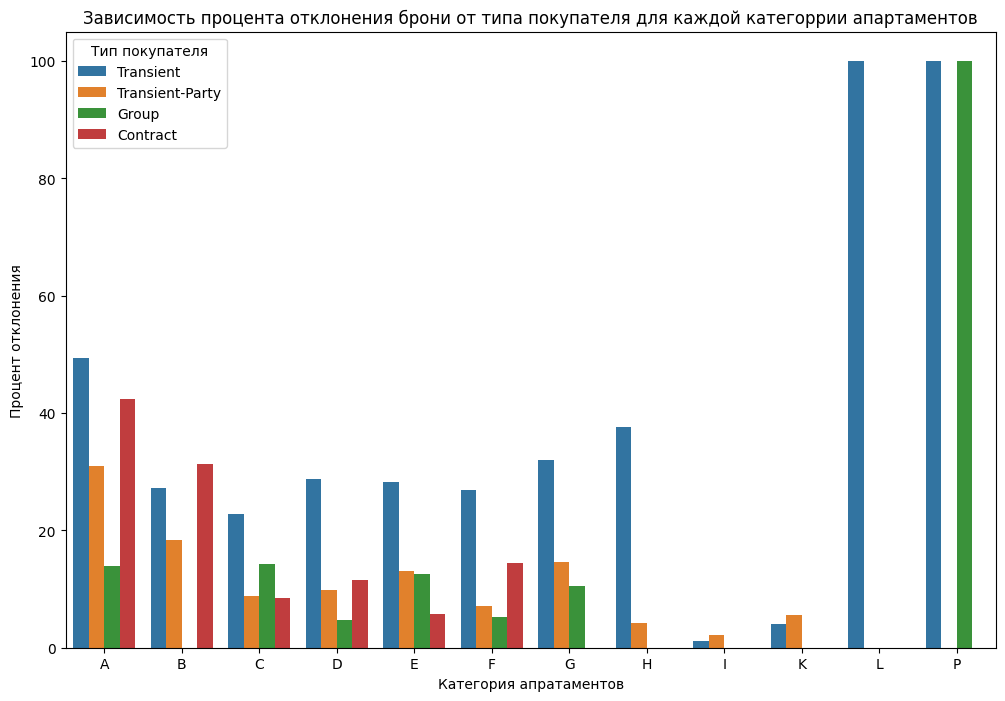

In [3]:
data = {
    'customer_type': [],
    'assigned_room_type': [],
    'canceled_percentage': []
}

res_df = pd.DataFrame(data)

j = 0
for customer_type in df['customer_type'].unique():
    for room_type in df['assigned_room_type'].unique():
        num_canceled = df[(df['customer_type']==customer_type) & (df['assigned_room_type']==room_type) & (df['is_canceled']==1)].shape[0]
        num = df[(df['customer_type']==customer_type) & (df['assigned_room_type']==room_type)].shape[0]
        if num!=0 and num_canceled!=0:
            canceled_percentage = num_canceled/num * 100
            res_df.loc[j]=[customer_type,room_type,canceled_percentage]
        else:
            res_df.loc[j]=[customer_type,room_type,0]
        j=j+1

plt.figure(figsize=(12,8))
sns.barplot(x='assigned_room_type', y='canceled_percentage',hue='customer_type', data = res_df.sort_values(by='assigned_room_type'))
plt.title('Зависимость процента отклонения брони от типа покупателя для каждой категоррии апартаментов')
plt.xlabel('Категория апратаментов')
plt.ylabel('Процент отклонения')
plt.legend(title='Тип покупателя')
plt.show()

#### Результаты данного пункта анализа
- Для любого типа аппартаментов (кроме B) чаще всего отклоняют брони клиенты типа "Transient".
- Для типа аппартаментов B чаще всего отклоняют брони клиенты типа "Contract".
- Меньшего всего отменяют брони аппаратаментов A,B,D,F клиенты типа "Group".
- Меньшего всего отменяют брони аппаратаментов С, P клиенты типов "Transient-party" и "Contract".
- Меньшего всего отменяют брони аппаратаментов E,G клиенты типа "Contract".
- Меньшего всего отменяют брони аппаратаментов H,I,K клиенты типов "Group" и "Contract".
- Меньшего всего отменяют брони аппаратаментов L клиенты типов "Group", "Contract" и "Transient-party".
### 3. Попытка установить влияние кол-ва заселяющихся на кол-во ночей брони.

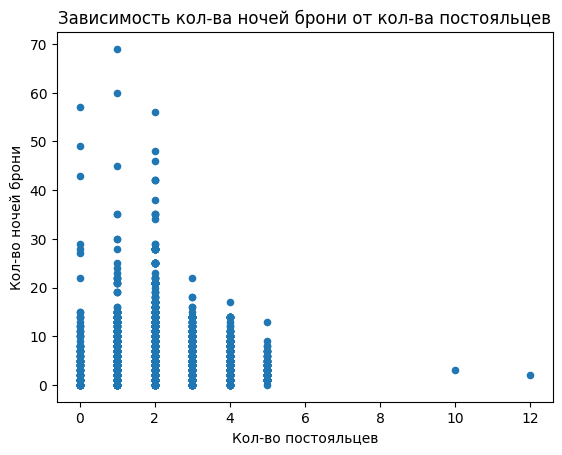

In [4]:
temp_df = df[df['is_canceled'] == 0]
temp_df = temp_df.assign(nights = temp_df['stays_in_weekend_nights']+temp_df['stays_in_week_nights'])
temp_df = temp_df.assign(humans = temp_df['adults']+temp_df['children']+temp_df['babies'])

temp_df.plot(
   x='humans', 
   y='nights', 
   kind='scatter'
)

plt.xlabel('Кол-во постояльцев')
plt.ylabel('Кол-во ночей брони')
plt.title('Зависимость кол-ва ночей брони от кол-ва постояльцев')
plt.show()


#### Результаты данного пункта анализа
- искомая зависимость не была установлена
- в основном кол-во ночей брони принадлежит интервалу [0,10].
### 4. Установка доминирующего источника клиентов.

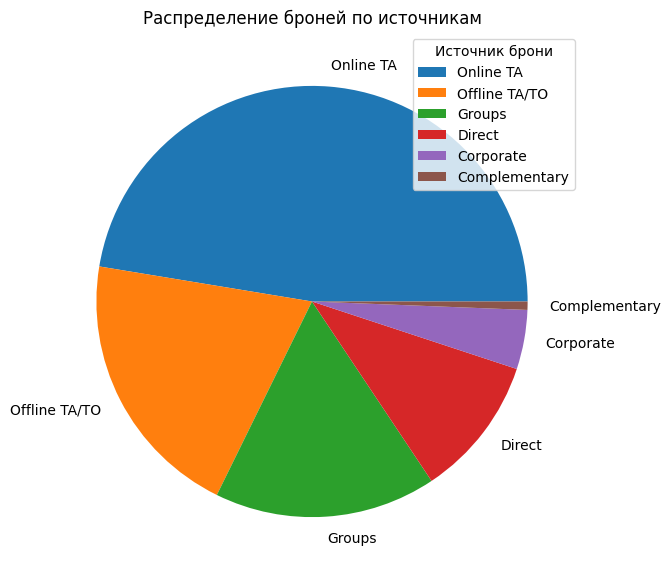

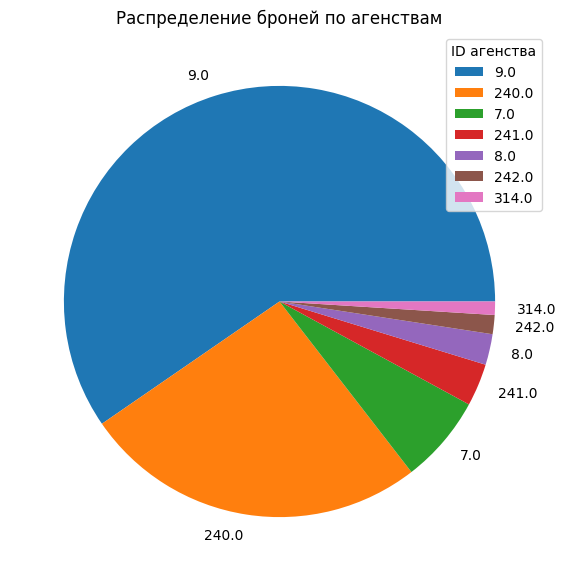

In [5]:
temp_df = df.assign(amount = 0)
temp_df = temp_df.groupby('market_segment')['amount'].count()

temp_df = pd.DataFrame(temp_df)
temp_df = temp_df.nlargest(6, ['amount']) 

temp_df.plot(
   y='amount', 
   kind='pie',
   figsize=(11,7)
)
plt.ylabel('')
plt.legend(title = 'Источник брони')
plt.title('Распределение броней по источникам')
plt.show()

temp_df = df.assign(amount = 0)
temp_df = temp_df[df['market_segment']=='Online TA']
temp_df = temp_df.groupby('agent')['amount'].count()

temp_df = pd.DataFrame(temp_df)
temp_df = temp_df.nlargest(7, ['amount']) 

temp_df.plot(
   y='amount', 
   kind='pie',
   figsize=(11,7)
)

plt.ylabel('')
plt.title('Распределение броней по агенствам')
plt.legend(title = 'ID агенства')
plt.show()

### Результаты данного пункта анализа
- Наиболее распространенным источником броней являются онлайн турагенства.
- Наиболее популярным турагенством является агенство с ID = 9.
## Информация о корреляции признаков
Для корреляционного анализа были выбраны признаки: 
- статус брони (отменен, успешен) 
- время между открытием брони и приездом
- является ли клиент постоянным
- кол-во успешных броней клиента
- время в листе ожидания
Основная причина выбора следующих признаков - прослеживаемое в реальной жизни взаимное влияние.

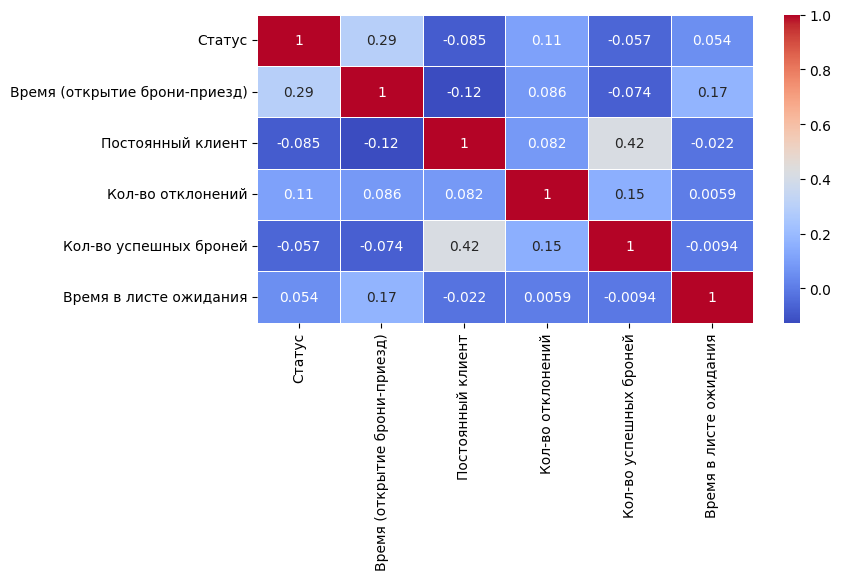

In [6]:
temp_df = df
numeric_columns = ['is_canceled', 'lead_time', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'days_in_waiting_list']
correlation_matrix = temp_df[numeric_columns].corr()
correlation_matrix.index = ['Статус', 'Время (открытие брони-приезд)', 'Постоянный клиент', 'Кол-во отклонений', 
                            'Кол-во успешных броней', 'Время в листе ожидания']
correlation_matrix.columns = correlation_matrix.index
plt.figure(figsize=(8,4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidth=0.5)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

### Результаты корреляционного анализа.
- Прослеживается значительная положительная корреляция между статусом и временем между открытием брони и приездом.
- Наибольшая положительная корреляция прослеживается между кол-вом успешных броней и тем, является ли клиент постоянным.
- Наибольшая значительная отрицательная корреляция прослеживается между тем, является ли клиент постоянным, и временем между открытием брони и клиентом.
- Остальные зависимости можно считать незначительными.